# Phishing URL Detection — Complete ML Pipeline
### Project

---
## 1.  Imports & Setup

In [31]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# Preprocessing & Pipeline
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# Dimensionality & Feature Selection
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import (SelectKBest, f_classif,
                                        mutual_info_classif, RFECV)
from sklearn.metrics.pairwise import euclidean_distances

# Models
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import (RandomForestClassifier,
                                     AdaBoostClassifier,
                                     GradientBoostingClassifier)
# Optional: XGBoost
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('⚠️  XGBoost not found → pip install xgboost  (using GradientBoosting instead)')

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              ConfusionMatrixDisplay)

# Optional: SMOTE
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print('⚠️  imbalanced-learn not found → pip install imbalanced-learn  (using class_weight instead)')
    
# Style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold'})
C = {'phish': '#e74c3c', 'legit': '#2ecc71', 'blue': '#3498db', 'orange': '#f39c12'}

RANDOM_STATE = 42
print('\n All imports successful')


 All imports successful


---
## 2.  Data Loading & Profiling

In [2]:
# Load Data 
df_raw = pd.read_csv('PhiUSIIL_Phishing_URL_Dataset.csv') 

print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)


Raw shape: (235795, 55)


,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  object 
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  object 
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  int64  
 5   TLD                         235795 non-null  object 
 6   URLSimilarityIndex          235795 non-null  float64
 7   CharContinuationRate        235795 non-null  float64
 8   TLDLegitimateProb           235795 non-null  float64
 9   URLCharProb                 235795 non-null  float64
 10  TLDLength                   235795 non-null  int64  
 11  NoOfSubDomain               235795 non-null  int64  
 12  HasObfuscation              235795 non-null  int64  
 13  NoOfObfuscated

In [4]:
df_raw.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


In [5]:
# Drop non-feature columns
drop_cols = ['URL', 'Title', 'Domain']     # identifiers / text cols
df_raw = df_raw.drop(columns=[c for c in drop_cols if c in df_raw.columns])

print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)

Raw shape: (235795, 52)


,URLLength,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,31,24,0,com,100.0,1.000000,0.522907,0.061933,3,1,...,0,0,1,34,20,28,119,0,124,1
1,23,16,0,de,100.0,0.666667,0.032650,0.050207,2,1,...,0,0,1,50,9,8,39,0,217,1
2,29,22,0,uk,100.0,0.866667,0.028555,0.064129,2,2,...,0,0,1,10,2,7,42,2,5,1


In [6]:
# Profile 

from ydata_profiling import ProfileReport

profile = ProfileReport(df_raw, title="Phishing URL Dataset Profile Report")
profile.to_file("phishing_url_profile_report_2.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00,  1.52it/s]


In [7]:
print('  DATASET PROFILE')
print('═'*55)
print(f'  Rows             : {df_raw.shape[0]:,}')
print(f'  Columns          : {df_raw.shape[1]}')
print(f'  Memory           : {df_raw.memory_usage(deep=True).sum()/1024:.1f} KB')
print(f'  Duplicate rows   : {df_raw.duplicated().sum()}')
print(f'  Missing values   : {df_raw.isnull().sum().sum()}')
print()

# dtype breakdown
print('  Data types:')
print(df_raw.dtypes.value_counts().to_string())

# Binary vs continuous
feat_cols   = [c for c in df_raw.columns if c != 'label']
binary_cols = [c for c in feat_cols if df_raw[c].nunique() <= 2]
cont_cols   = [c for c in feat_cols if c not in binary_cols]
print(f'\n  Binary features     : {len(binary_cols)}')
print(f'  Continuous features : {len(cont_cols)}')
print(f'  Total features      : {len(feat_cols)}')

  DATASET PROFILE
═══════════════════════════════════════════════════════
  Rows             : 235,795
  Columns          : 52
  Memory           : 105869.4 KB
  Duplicate rows   : 808
  Missing values   : 0

  Data types:
int64      41
float64    10
object      1

  Binary features     : 19
  Continuous features : 32
  Total features      : 51


---
## 3.  Preprocessing

In [8]:
# Separate X / y 
df = df_raw.copy()

X_all = df.drop(columns=['label'])
y_all = df['label']

print(f'X shape : {X_all.shape}')
print(f'y shape : {y_all.shape}')
print(f'Features: {list(X_all.columns)}')

X shape : (235795, 51)
y shape : (235795,)
Features: ['URLLength', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']


In [9]:
# ─── 3.1  Encode `TLD` feature (frequency + top-N one-hot) ─────────────────────
if 'TLD' in X_all.columns:
    top_n = 10
    # ensure string and fill missing
    X_all['TLD'] = X_all['TLD'].fillna('unknown').astype(str)

    # frequency encoding
    tld_counts = X_all['TLD'].value_counts()
    X_all['TLD_freq'] = X_all['TLD'].map(tld_counts).fillna(0).astype(int)

    # group rare TLDs into 'OTHER' and one-hot encode the top N
    top_tlds = tld_counts.nlargest(top_n).index.tolist()
    X_all['TLD_topN'] = X_all['TLD'].where(X_all['TLD'].isin(top_tlds), 'OTHER')
    tld_dummies = pd.get_dummies(X_all['TLD_topN'], prefix='TLD')
    X_all = pd.concat([X_all, tld_dummies], axis=1)

    # Drop original string TLD column (can't be scaled/used by models)
    # Keep TLD_freq (numeric) and the one-hot dummy columns instead
    X_all = X_all.drop(columns=['TLD', 'TLD_topN'])
    print(f'   Columns now: {list(X_all.columns[-5:])} ...')
    print(f"Encoded TLD: added `TLD_freq` and one-hot columns for top {top_n} TLDs (others -> 'OTHER')")
else:
    print('No `TLD` column found in dataset; skipping TLD encoding')

print('\n--- 3 rows after TLD encoding ---')
print(X_all.head(3).to_string())

   Columns now: ['TLD_io', 'TLD_net', 'TLD_org', 'TLD_ru', 'TLD_uk'] ...
Encoded TLD: added `TLD_freq` and one-hot columns for top 10 TLDs (others -> 'OTHER')

--- 3 rows after TLD encoding ---
   URLLength  DomainLength  IsDomainIP  URLSimilarityIndex  CharContinuationRate  TLDLegitimateProb  URLCharProb  TLDLength  NoOfSubDomain  HasObfuscation  NoOfObfuscatedChar  ObfuscationRatio  NoOfLettersInURL  LetterRatioInURL  NoOfDegitsInURL  DegitRatioInURL  NoOfEqualsInURL  NoOfQMarkInURL  NoOfAmpersandInURL  NoOfOtherSpecialCharsInURL  SpacialCharRatioInURL  IsHTTPS  LineOfCode  LargestLineLength  HasTitle  DomainTitleMatchScore  URLTitleMatchScore  HasFavicon  Robots  IsResponsive  NoOfURLRedirect  NoOfSelfRedirect  HasDescription  NoOfPopup  NoOfiFrame  HasExternalFormSubmit  HasSocialNet  HasSubmitButton  HasHiddenFields  HasPasswordField  Bank  Pay  Crypto  HasCopyrightInfo  NoOfImage  NoOfCSS  NoOfJS  NoOfSelfRef  NoOfEmptyRef  NoOfExternalRef  TLD_freq  TLD_OTHER  TLD_app  TLD_au  T

In [10]:
#  Handle Missing Values 
print(f'Missing before: {X_all.isnull().sum().sum()}')
X_all = X_all.fillna(X_all.median(numeric_only=True))
print(f'Missing after : {X_all.isnull().sum().sum()}')

Missing before: 0
Missing after : 0


In [11]:
# ─── 4.5  Train / Test Split (stratified 80/20) ───────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)

print(f'Train : {X_train.shape}  |  {dict(y_train.value_counts().sort_index())}')
print(f'Test  : {X_test.shape}   |  {dict(y_test.value_counts().sort_index())}')

# Scale (needed for LR and PCA)
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)   # fit on train only!
X_test_sc   = scaler.transform(X_test)         # transform test
print('✅ StandardScaler fitted on training set only (no data leakage)')

Train : (188636, 62)  |  {0: np.int64(80756), 1: np.int64(107880)}
Test  : (47159, 62)   |  {0: np.int64(20189), 1: np.int64(26970)}
✅ StandardScaler fitted on training set only (no data leakage)


---
## 5. ⚖️ Class Imbalance

In [12]:
# ─── 5.1  Measure Imbalance ───────────────────────────────────────────────────
counts    = y_train.value_counts().sort_index()
imb_ratio = counts.max() / counts.min()

print('═'*45)
print('  CLASS IMBALANCE (Training Set)')
print('═'*45)
print(f'  Phishing   (0) : {counts.get(0,0):,}')
print(f'  Legitimate (1) : {counts.get(1,0):,}')
print(f'  Ratio          : {imb_ratio:.2f} : 1')

if imb_ratio < 1.5:
    print('\n  ✅ Balanced — using class_weight="balanced" as best-practice')
elif imb_ratio < 4:
    print('\n  ⚠️  Moderate imbalance — SMOTE recommended')
else:
    print('\n  ❌ Severe imbalance — SMOTE strongly recommended')

cw_arr  = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = dict(enumerate(cw_arr))
print(f'  Class weights  : {cw_dict}')

═════════════════════════════════════════════
  CLASS IMBALANCE (Training Set)
═════════════════════════════════════════════
  Phishing   (0) : 80,756
  Legitimate (1) : 107,880
  Ratio          : 1.34 : 1

  ✅ Balanced — using class_weight="balanced" as best-practice
  Class weights  : {0: np.float64(1.1679379860319976), 1: np.float64(0.8742862439747868)}


In [13]:
label_map = {0: 'Phishing', 1: 'Legitimate'}  # for plot labels

# ─── 5.2  Apply SMOTE (if available) ─────────────────────────────────────────
if SMOTE_AVAILABLE and imb_ratio >= 1.5:
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    X_train_res_sc = scaler.transform(X_train_res)   # scale resampled

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    for ax, (title, ydata) in zip(axes, [
        ('Before SMOTE', y_train), ('After SMOTE', y_train_res)
    ]):
        c = pd.Series(ydata).value_counts().sort_index()
        ax.bar([label_map[k] for k in c.index], c.values,
               color=[C['phish'],C['legit']], edgecolor='black')
        ax.set_title(title); ax.set_ylabel('Count')
        for i,v in enumerate(c.values):
            ax.text(i, v+5, str(v), ha='center', fontweight='bold')
    plt.tight_layout(); plt.show()

    USE_SMOTE = True
    print('✅ SMOTE applied')
else:
    X_train_res, y_train_res    = X_train.copy(), y_train.copy()
    X_train_res_sc              = X_train_sc.copy()
    USE_SMOTE                   = False
    print('Using class_weight="balanced" — SMOTE skipped')

Using class_weight="balanced" — SMOTE skipped


---
## 6. 🌌 Curse of Dimensionality Analysis

> **Why this matters:** With too many features and too few samples, distances between points become meaningless, models overfit, and generalisation collapses. We must quantify this before selecting features.

In [14]:
# ─── 6.1  Samples-to-Features Ratio ──────────────────────────────────────────
n_samples  = X_train.shape[0]
n_features = X_train.shape[1]
ratio      = n_samples / n_features

print('═'*52)
print('  CURSE OF DIMENSIONALITY — KEY NUMBERS')
print('═'*52)
print(f'  Training samples : {n_samples:,}')
print(f'  Features         : {n_features}')
print(f'  Sample:Feature   : {ratio:.1f} : 1')
print()
print('  Rule-of-thumb thresholds:')
print(f'  • Good (>30:1)     → need {n_features*30:,} samples   ', '✅' if ratio >= 30 else '❌')
print(f'  • Acceptable(>10:1)→ need {n_features*10:,} samples  ', '✅' if ratio >= 10 else '❌')
print(f'  • Risky (<10:1)    → current ratio = {ratio:.1f}       ', '⚠️'  if ratio < 10 else '✅')
print()

# How many features should we ideally have?
ideal_max = n_samples // 30
acceptable_max = n_samples // 10
print(f'  → For {n_samples} samples, ideal max features   : {ideal_max}')
print(f'  → For {n_samples} samples, acceptable max feats : {acceptable_max}')
print(f'  → We currently have                           : {n_features} features')
print(f'  → We should reduce to around                  : {acceptable_max}–{ideal_max} features')

════════════════════════════════════════════════════
  CURSE OF DIMENSIONALITY — KEY NUMBERS
════════════════════════════════════════════════════
  Training samples : 188,636
  Features         : 62
  Sample:Feature   : 3042.5 : 1

  Rule-of-thumb thresholds:
  • Good (>30:1)     → need 1,860 samples    ✅
  • Acceptable(>10:1)→ need 620 samples   ✅
  • Risky (<10:1)    → current ratio = 3042.5        ✅

  → For 188636 samples, ideal max features   : 6287
  → For 188636 samples, acceptable max feats : 18863
  → We currently have                           : 62 features
  → We should reduce to around                  : 18863–6287 features


---
## 7. ✂️ Feature Selection — Mutual Information

**Why Mutual Information?**  
MI measures statistical dependency between each feature and the label — it captures **both linear and non-linear** relationships, unlike correlation or ANOVA F-score which assume linearity. It's a well-justified single method for this dataset.

Target: reduce to **`K_FINAL`** features — computed from the CoD samples:features analysis above.

In [15]:
# ─── 7.0  Decide target K (from CoD analysis) ─────────────────────────────────
# acceptable_max was computed in Section 6.1
# Cap at 20 max for good model performance
K_FINAL = min(acceptable_max, 20)
K_FINAL = max(K_FINAL, 10)    # at least 10 features

print(f'Target feature count K = {K_FINAL}')
print(f'(Justified by samples:features ratio — ensures we stay out of CoD zone)')

Target feature count K = 20
(Justified by samples:features ratio — ensures we stay out of CoD zone)


In [16]:
# ─── 7.1  Feature Selection — Mutual Information ─────────────────────────────
# MI measures how much information each feature shares with the label.
# It captures both linear and non-linear dependencies — ideal for this dataset.

mi_scores = mutual_info_classif(X_train_res, y_train_res, random_state=RANDOM_STATE)
mi_scores = pd.Series(mi_scores, index=X_train_res.columns).sort_values(ascending=False)

print(f'Top {K_FINAL} features by Mutual Information:')
print(mi_scores.head(K_FINAL).round(4).to_string())

Top 20 features by Mutual Information:
URLSimilarityIndex            0.6769
LineOfCode                    0.6008
NoOfExternalRef               0.5605
NoOfImage                     0.5443
NoOfSelfRef                   0.5269
NoOfJS                        0.5015
LargestLineLength             0.4861
NoOfCSS                       0.4468
HasSocialNet                  0.4111
LetterRatioInURL              0.3835
HasCopyrightInfo              0.3455
HasDescription                0.2999
IsHTTPS                       0.2514
NoOfOtherSpecialCharsInURL    0.2415
DomainTitleMatchScore         0.2095
HasSubmitButton               0.2063
SpacialCharRatioInURL         0.2039
TLDLegitimateProb             0.1950
URLTitleMatchScore            0.1892
TLD_freq                      0.1884


In [17]:
# ─── 7.2  Visualise MI Scores ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Selection — Mutual Information Scores', fontsize=14)

# Bar chart: all features
mi_sorted = mi_scores.sort_values()
clrs = [C['phish'] if i >= len(mi_sorted) - K_FINAL else C['blue']
        for i in range(len(mi_sorted))]
mi_sorted.plot(kind='barh', ax=axes[0], color=clrs, edgecolor='black', lw=0.2)
axes[0].axvline(mi_scores.iloc[K_FINAL - 1], color='red', ls='--', lw=1.5,
                label=f'Cut-off (K={K_FINAL})')
axes[0].set_title('All Features — MI Score\n(Red = selected top K)', fontsize=11)
axes[0].set_xlabel('Mutual Information Score')
axes[0].legend()

# Bar chart: top K only
mi_scores.head(K_FINAL).sort_values().plot(
    kind='barh', ax=axes[1], color=C['phish'], edgecolor='black', lw=0.3)
axes[1].set_title(f'Top {K_FINAL} Selected Features', fontsize=11)
axes[1].set_xlabel('Mutual Information Score')

plt.tight_layout(); plt.show()

In [18]:
# ─── 7.3  Select Final Features from MI ──────────────────────────────────────
selected_features = mi_scores.head(K_FINAL).index.tolist()

print(f'✅ {len(selected_features)} features selected by Mutual Information:')
for rank, feat in enumerate(selected_features, 1):
    print(f'   {rank:>2}. {feat:<40}  MI = {mi_scores[feat]:.4f}')

✅ 20 features selected by Mutual Information:
    1. URLSimilarityIndex                        MI = 0.6769
    2. LineOfCode                                MI = 0.6008
    3. NoOfExternalRef                           MI = 0.5605
    4. NoOfImage                                 MI = 0.5443
    5. NoOfSelfRef                               MI = 0.5269
    6. NoOfJS                                    MI = 0.5015
    7. LargestLineLength                         MI = 0.4861
    8. NoOfCSS                                   MI = 0.4468
    9. HasSocialNet                              MI = 0.4111
   10. LetterRatioInURL                          MI = 0.3835
   11. HasCopyrightInfo                          MI = 0.3455
   12. HasDescription                            MI = 0.2999
   13. IsHTTPS                                   MI = 0.2514
   14. NoOfOtherSpecialCharsInURL                MI = 0.2415
   15. DomainTitleMatchScore                     MI = 0.2095
   16. HasSubmitButton                 

In [19]:
# ─── 7.4  Apply Selection — Build Final Datasets ──────────────────────────────
# These are the ONLY datasets used for model training from here on
X_train_sel    = X_train_res[selected_features].values     # tree-based models
X_test_sel     = X_test[selected_features].values
y_train_sel    = y_train_res.values
y_test_arr     = y_test.values

# Scaled version for Logistic Regression
sc_final       = StandardScaler()
X_train_sel_sc = sc_final.fit_transform(X_train_sel)
X_test_sel_sc  = sc_final.transform(X_test_sel)

new_ratio = len(X_train_sel) / len(selected_features)
print(f'Before selection : {n_features} features  |  sample:feature = {n_samples/n_features:.1f}:1')
print(f'After  selection : {len(selected_features)} features  |  sample:feature = {new_ratio:.1f}:1')
print(f'\n✅ Now well outside the Curse of Dimensionality danger zone!')

Before selection : 62 features  |  sample:feature = 3042.5:1
After  selection : 20 features  |  sample:feature = 9431.8:1

✅ Now well outside the Curse of Dimensionality danger zone!


---
## 8. 🤖 Model Training & Cross-Validation

In [20]:
# ─── 8.1  Define Models ───────────────────────────────────────────────────────
if XGB_AVAILABLE:
    boost_model = xgb.XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
    )
    boost_name = 'XGBoost'
else:
    boost_model = GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5,
        subsample=0.8, random_state=RANDOM_STATE
    )
    boost_name = 'GradientBoosting'

# Each model gets the right X (scaled for LR, raw for trees)
models = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, class_weight='balanced',
                                     C=1.0, random_state=RANDOM_STATE),
        'Xtr': X_train_sel_sc, 'Xte': X_test_sel_sc
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(max_depth=8, class_weight='balanced',
                                         min_samples_leaf=5, random_state=RANDOM_STATE),
        'Xtr': X_train_sel, 'Xte': X_test_sel
    },
    'Random Forest': {
        'model': RandomForestClassifier(n_estimators=200, max_depth=12,
                                         class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
        'Xtr': X_train_sel, 'Xte': X_test_sel
    },
    'AdaBoost': {
        'model': AdaBoostClassifier(n_estimators=150, learning_rate=0.5,
                                     random_state=RANDOM_STATE),
        'Xtr': X_train_sel, 'Xte': X_test_sel
    },
    boost_name: {
        'model': boost_model,
        'Xtr': X_train_sel, 'Xte': X_test_sel
    }
}

print(f'Models: {list(models.keys())}')
print(f'Training on {len(selected_features)} selected features')

Models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'AdaBoost', 'XGBoost']
Training on 20 selected features


In [21]:
# ─── 8.2  5-Fold Stratified Cross-Validation ──────────────────────────────────
cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_metrics  = ['accuracy','precision','recall','f1','roc_auc']

cv_results  = {}
trained     = {}

print('Running 5-Fold Stratified Cross-Validation...')
print('═'*65)

for name, info in models.items():
    print(f'\n  ▶ {name}')
    scores = cross_validate(
        info['model'], info['Xtr'], y_train_sel,
        cv=cv, scoring=cv_metrics,
        return_train_score=True, n_jobs=-1
    )
    info['model'].fit(info['Xtr'], y_train_sel)   # final fit on full train
    trained[name] = info['model']

    cv_results[name] = {
        'CV Accuracy' : scores['test_accuracy'].mean(),
        'CV Precision': scores['test_precision'].mean(),
        'CV Recall'   : scores['test_recall'].mean(),
        'CV F1'       : scores['test_f1'].mean(),
        'CV AUC'      : scores['test_roc_auc'].mean(),
        'CV Acc Std'  : scores['test_accuracy'].std(),
        'Train Acc'   : scores['train_accuracy'].mean(),
        'Overfit Gap' : scores['train_accuracy'].mean() - scores['test_accuracy'].mean()
    }
    r = cv_results[name]
    print(f'    Accuracy  : {r["CV Accuracy"]:.4f} ± {r["CV Acc Std"]:.4f}')
    print(f'    F1-Score  : {r["CV F1"]:.4f}')
    print(f'    AUC-ROC   : {r["CV AUC"]:.4f}')
    print(f'    Overfit   : {r["Overfit Gap"]:.4f}  {"⚠️" if r["Overfit Gap"]>0.05 else "✅"}')

cv_df = pd.DataFrame(cv_results).T
print('\n── Cross-Validation Summary ──')
display(
    cv_df[['CV Accuracy','CV Precision','CV Recall','CV F1','CV AUC','Overfit Gap']]
    .round(4)
    .style
    .highlight_max(color='#c6efce', subset=['CV Accuracy','CV F1','CV AUC'])
    .highlight_min(color='#ffc7ce', subset=['Overfit Gap'])
    .format('{:.4f}')
)

Running 5-Fold Stratified Cross-Validation...
═════════════════════════════════════════════════════════════════

  ▶ Logistic Regression
    Accuracy  : 0.9998 ± 0.0001
    F1-Score  : 0.9998
    AUC-ROC   : 1.0000
    Overfit   : 0.0000  ✅

  ▶ Decision Tree
    Accuracy  : 1.0000 ± 0.0000
    F1-Score  : 1.0000
    AUC-ROC   : 1.0000
    Overfit   : -0.0000  ✅

  ▶ Random Forest
    Accuracy  : 1.0000 ± 0.0000
    F1-Score  : 1.0000
    AUC-ROC   : 1.0000
    Overfit   : 0.0000  ✅

  ▶ AdaBoost
    Accuracy  : 1.0000 ± 0.0000
    F1-Score  : 1.0000
    AUC-ROC   : 1.0000
    Overfit   : 0.0000  ✅

  ▶ XGBoost
    Accuracy  : 1.0000 ± 0.0000
    F1-Score  : 1.0000
    AUC-ROC   : 1.0000
    Overfit   : 0.0000  ✅

── Cross-Validation Summary ──


,CV Accuracy,CV Precision,CV Recall,CV F1,CV AUC,Overfit Gap
Logistic Regression,0.9998,0.9997,1.0000,0.9998,1.0000,0.0000
Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000,-0.0000
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000
AdaBoost,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000
XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000


---
## 9. 📈 Model Evaluation

In [22]:
# ─── 9.1  Test Set Predictions ────────────────────────────────────────────────
test_results = {}
preds        = {}

for name, info in models.items():
    y_pred = trained[name].predict(info['Xte'])
    y_prob = trained[name].predict_proba(info['Xte'])[:, 1]
    preds[name] = {'y_pred': y_pred, 'y_prob': y_prob}
    test_results[name] = {
        'Accuracy' : accuracy_score(y_test_arr, y_pred),
        'Precision': precision_score(y_test_arr, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test_arr, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_test_arr, y_pred, zero_division=0),
        'AUC-ROC'  : roc_auc_score(y_test_arr, y_prob)
    }

results_df      = pd.DataFrame(test_results).T
best_name       = results_df['F1-Score'].idxmax()

print('Test Set Results:')
display(
    results_df.round(4)
    .style.highlight_max(color='#c6efce')
    .highlight_min(color='#ffc7ce')
    .format('{:.4f}')
)
print(f'\n🏆 Best Model (by F1): {best_name}')

Test Set Results:


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Logistic Regression,0.9997,0.9996,1.0000,0.9998,1.0000
Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
AdaBoost,1.0000,1.0000,1.0000,1.0000,1.0000
XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000



🏆 Best Model (by F1): Decision Tree


In [23]:
# ─── 9.2  Classification Reports ──────────────────────────────────────────────
for name in models:
    print(f'\n{"─"*50}\n  {name}\n{"─"*50}')
    print(classification_report(y_test_arr, preds[name]['y_pred'],
                                  target_names=['Phishing','Legitimate']))


──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    Phishing       1.00      1.00      1.00     20189
  Legitimate       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159


──────────────────────────────────────────────────
  Decision Tree
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    Phishing       1.00      1.00      1.00     20189
  Legitimate       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159


──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────

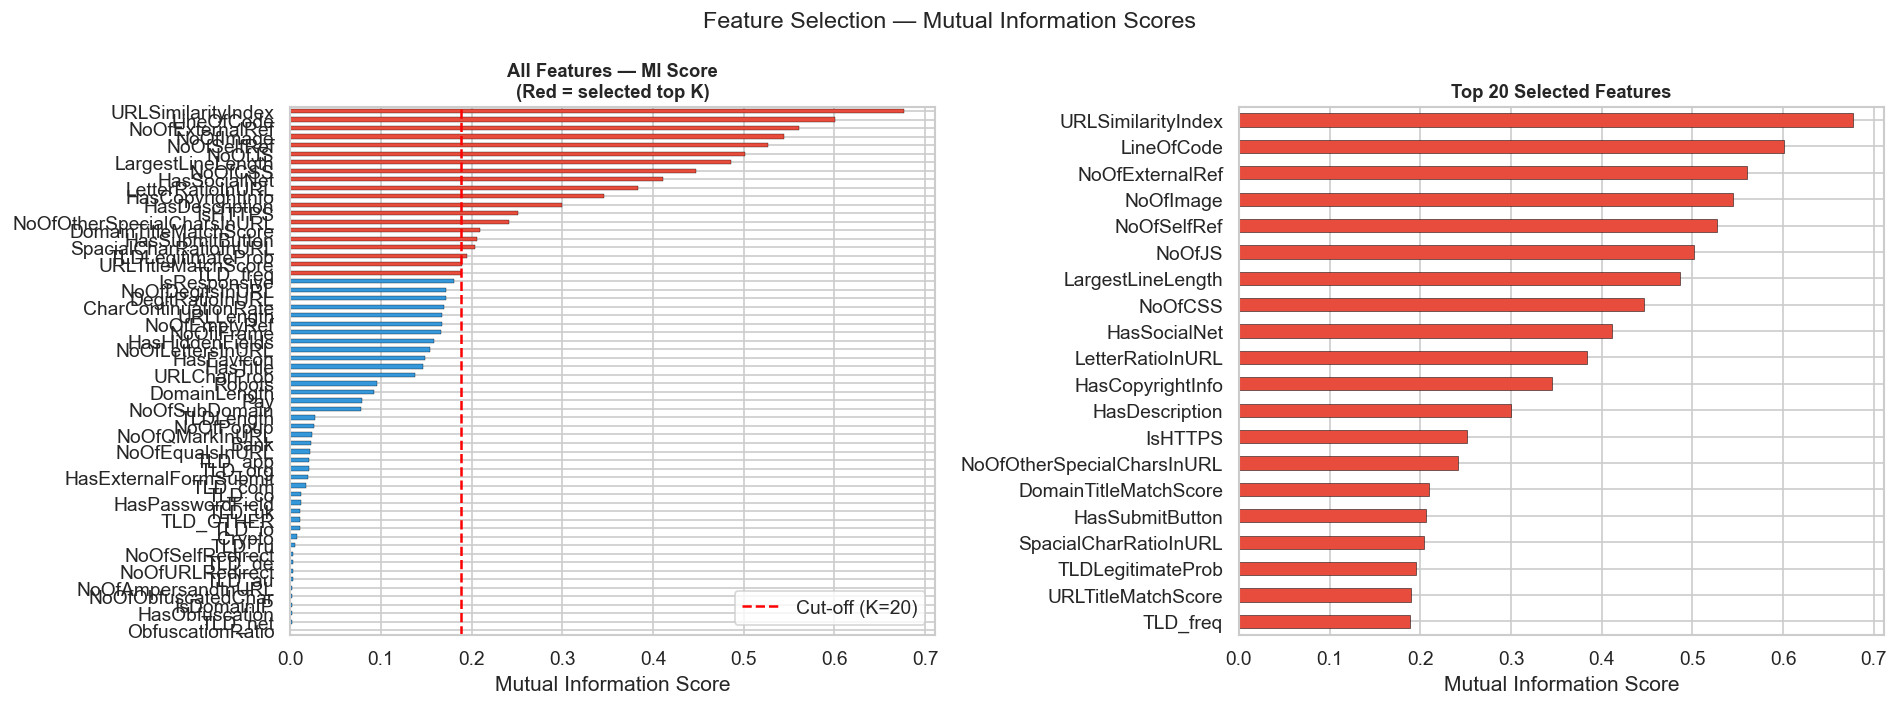

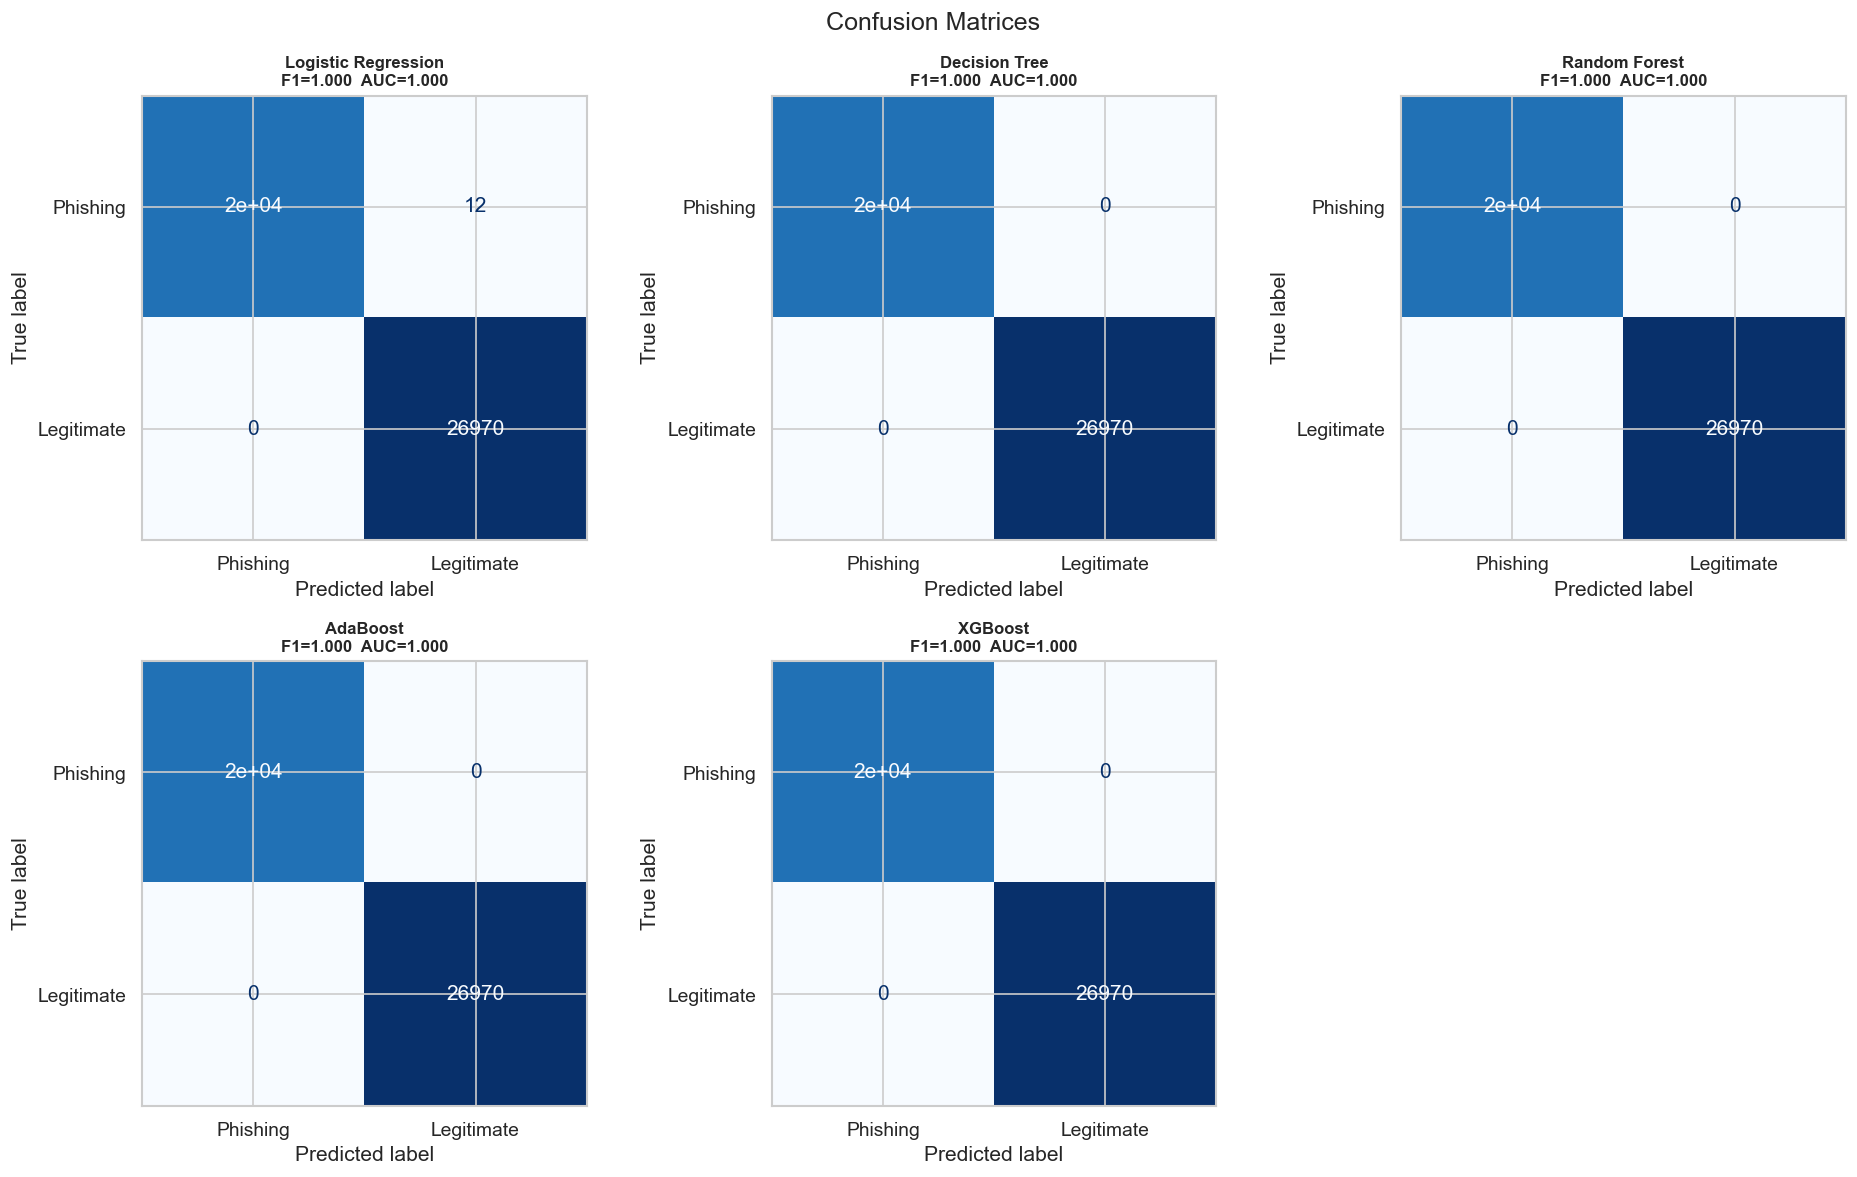

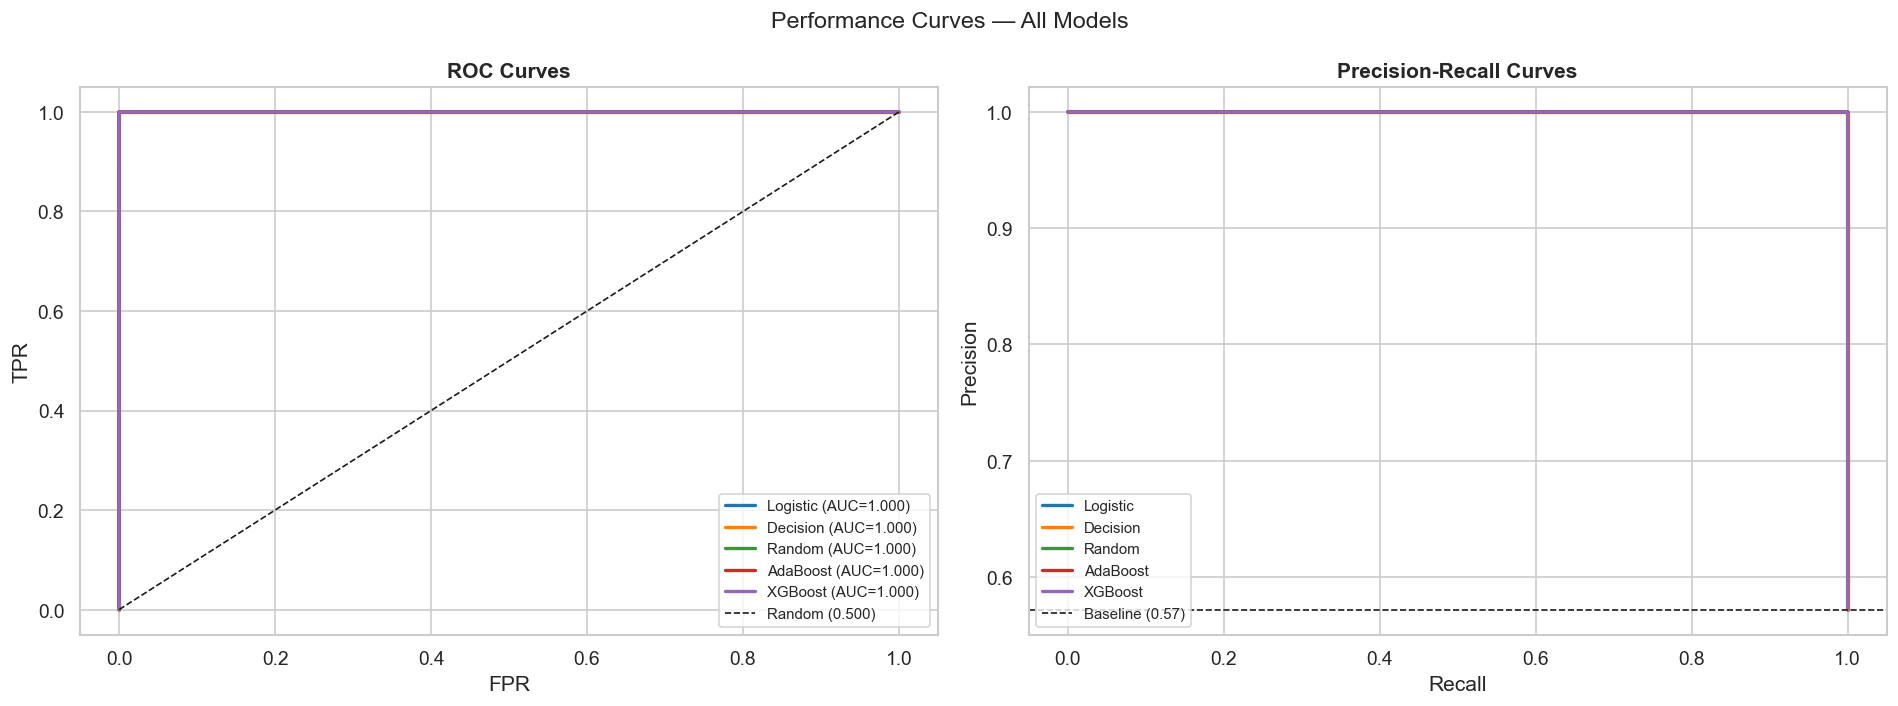

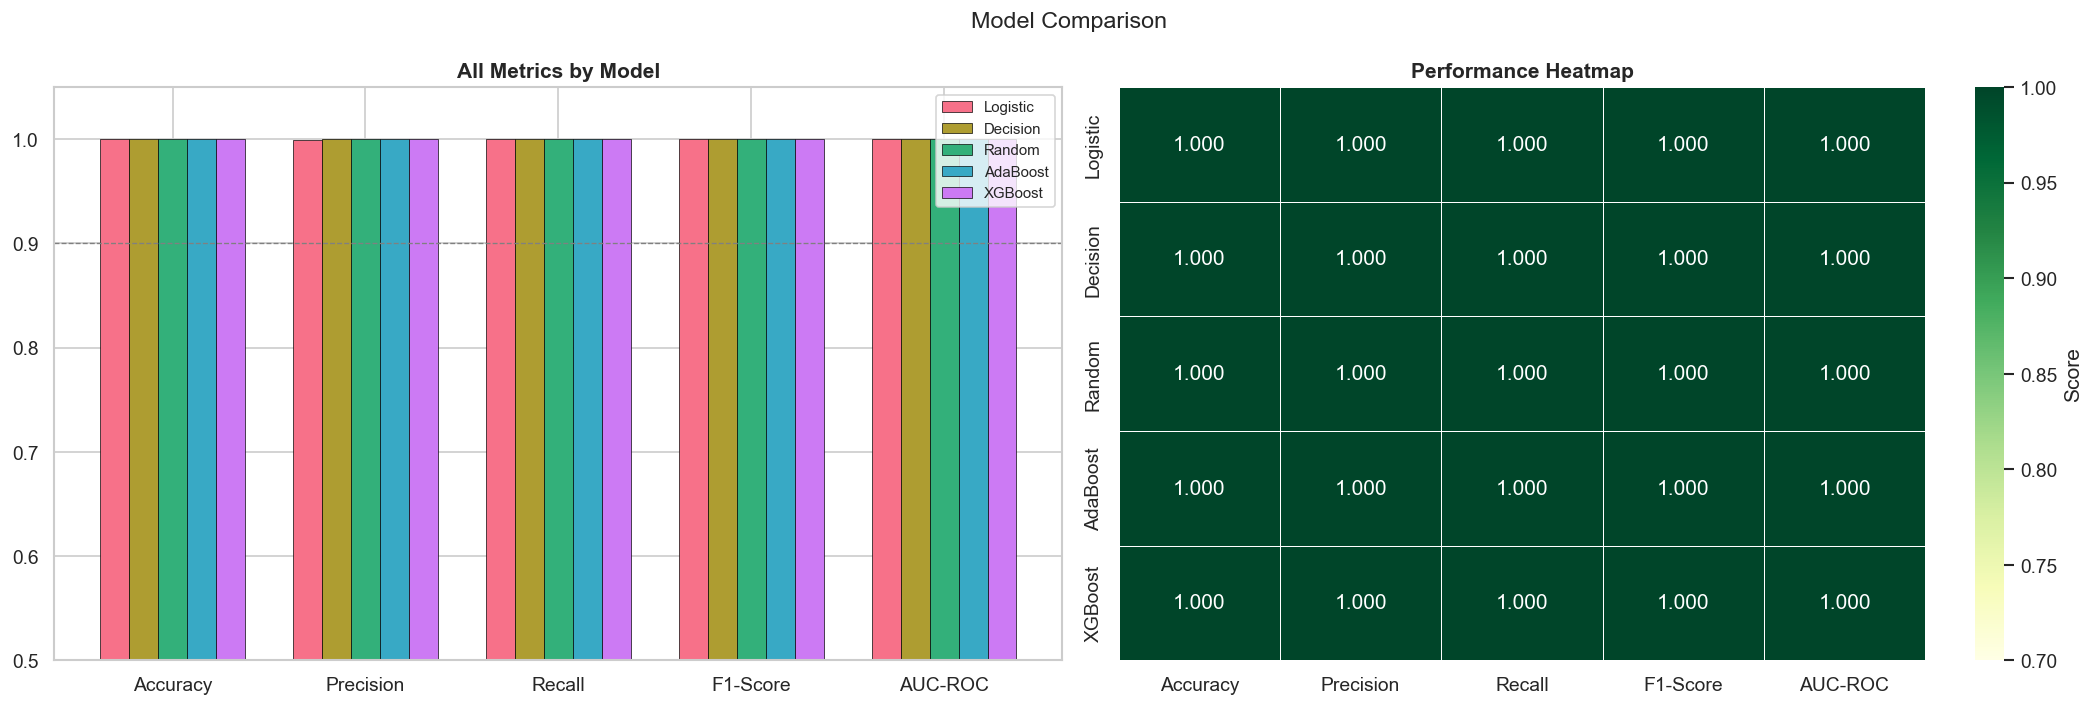

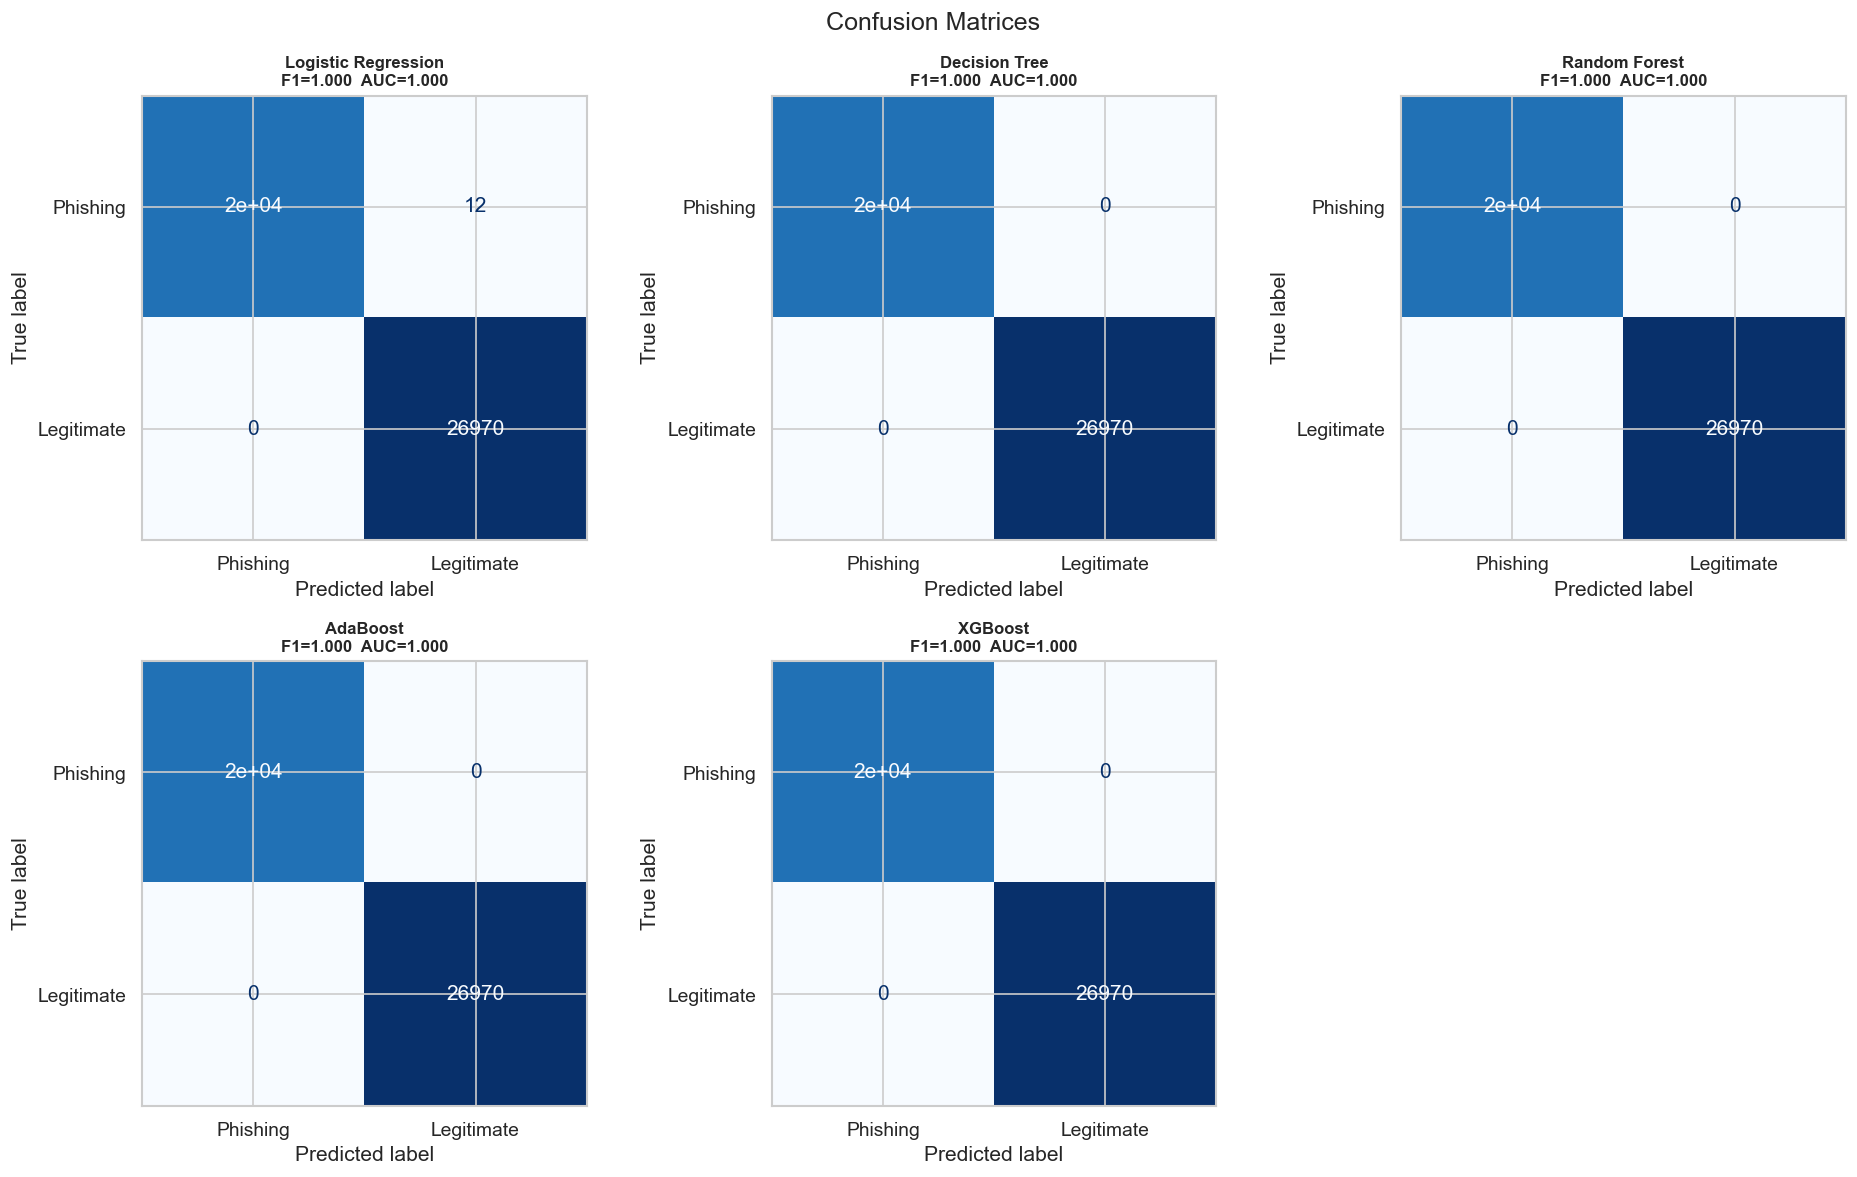

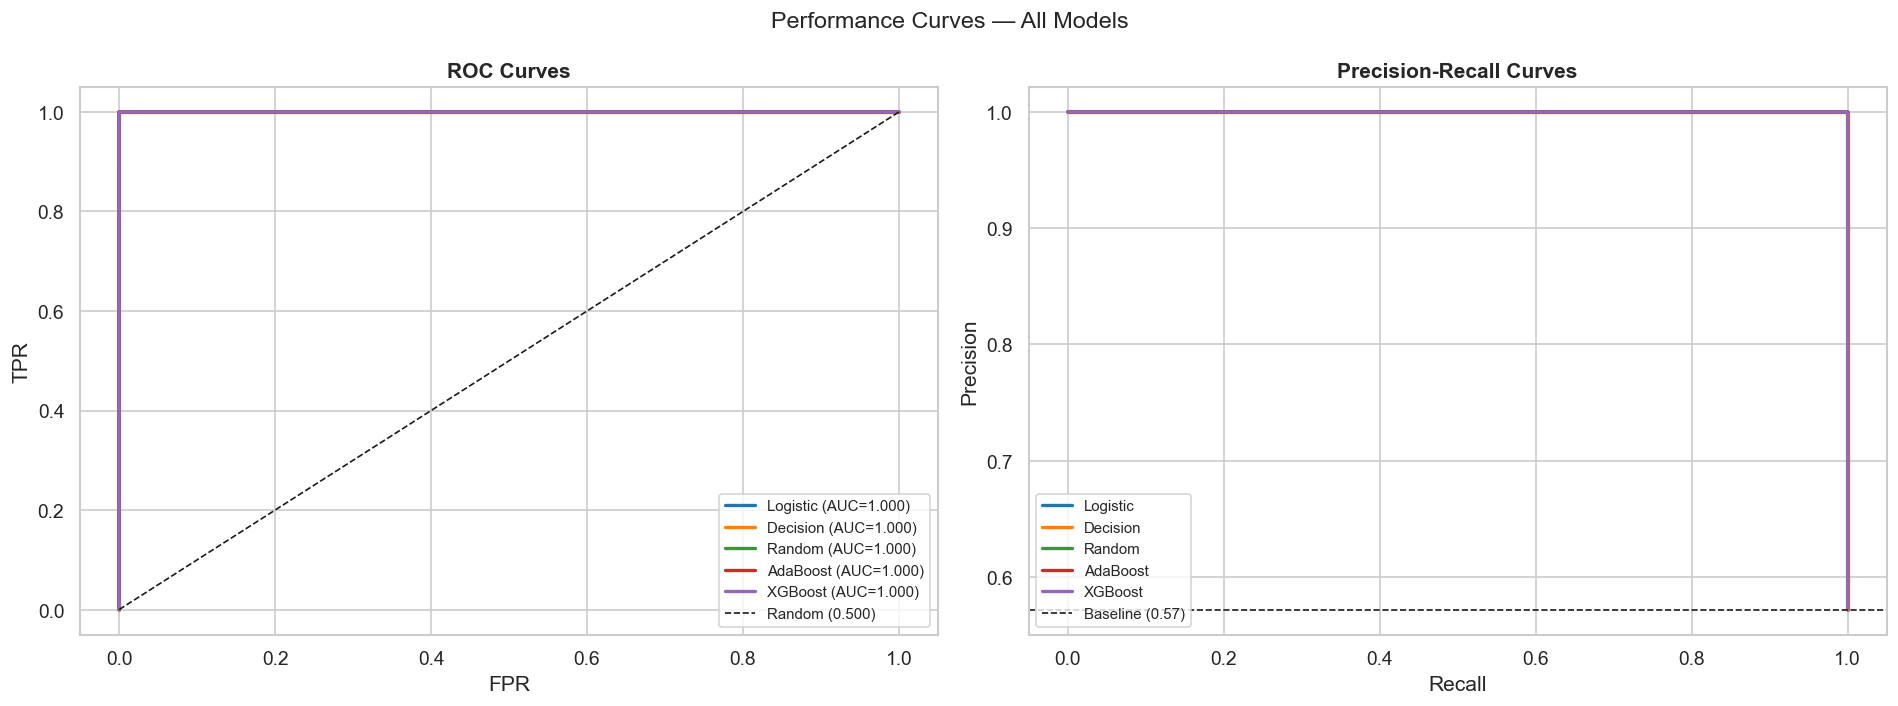

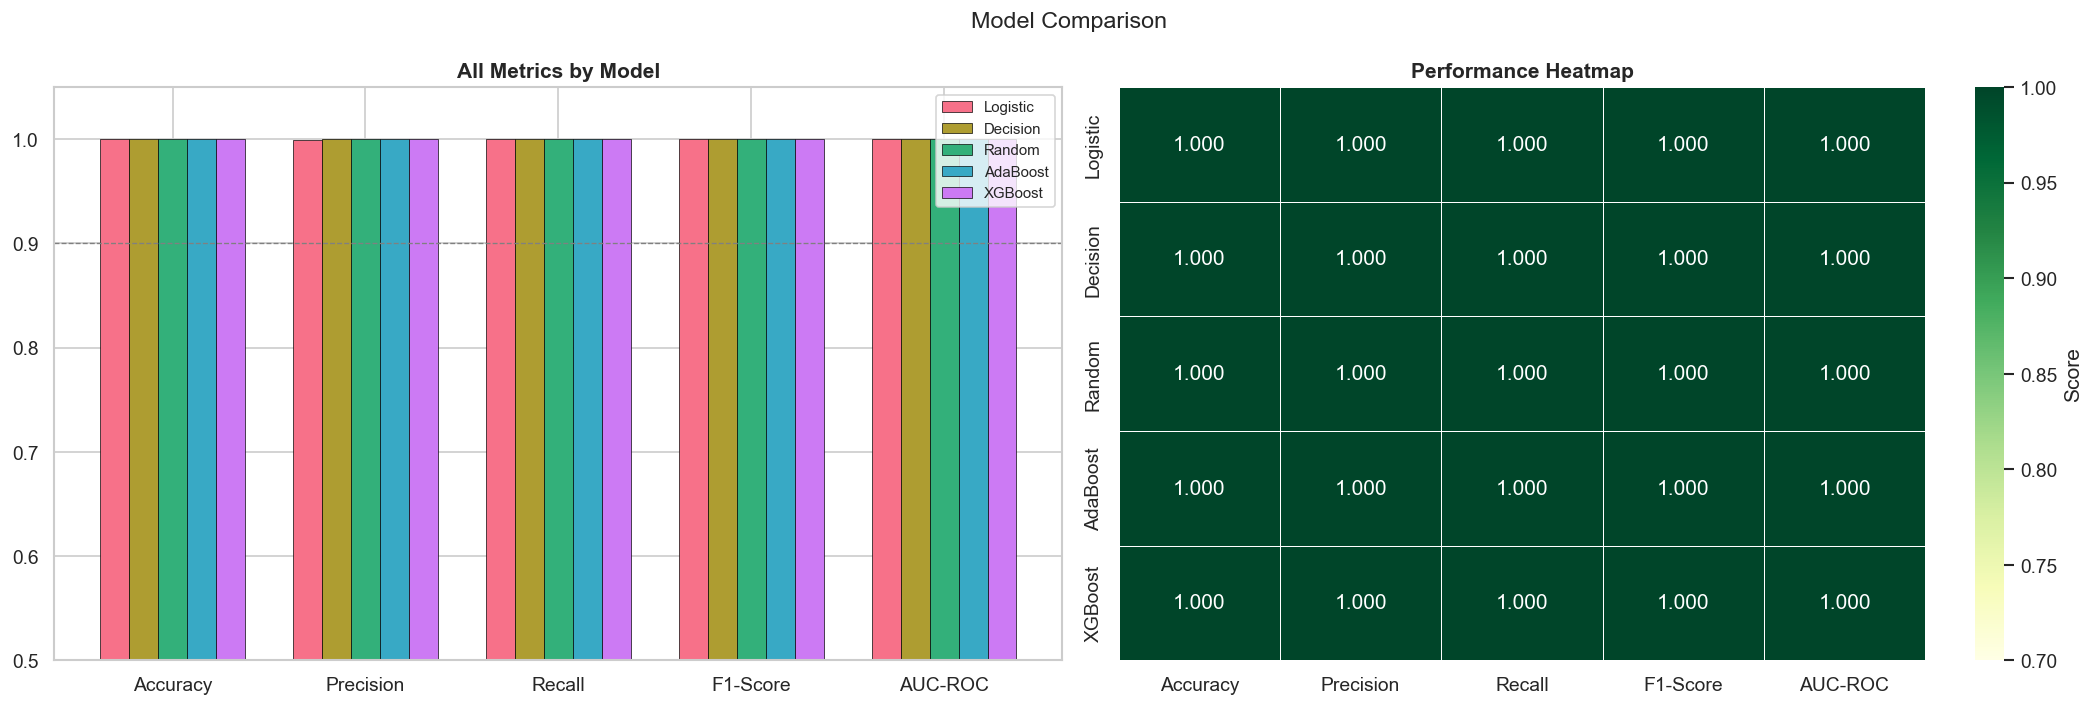

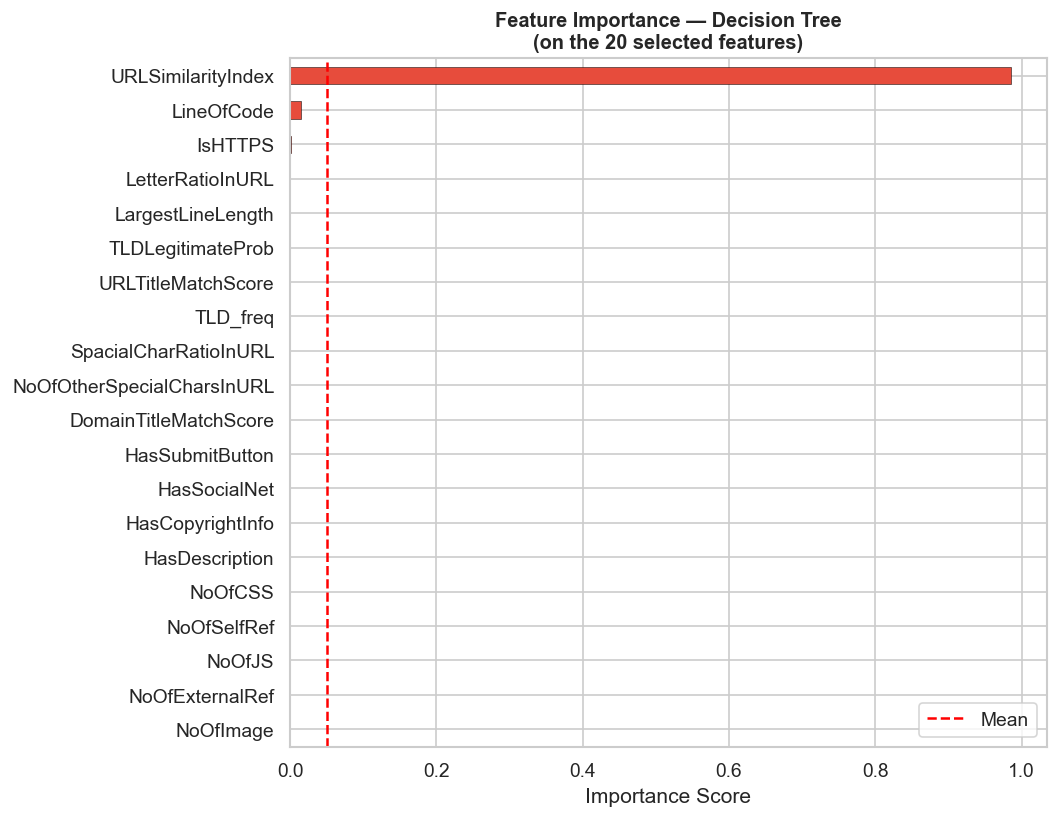

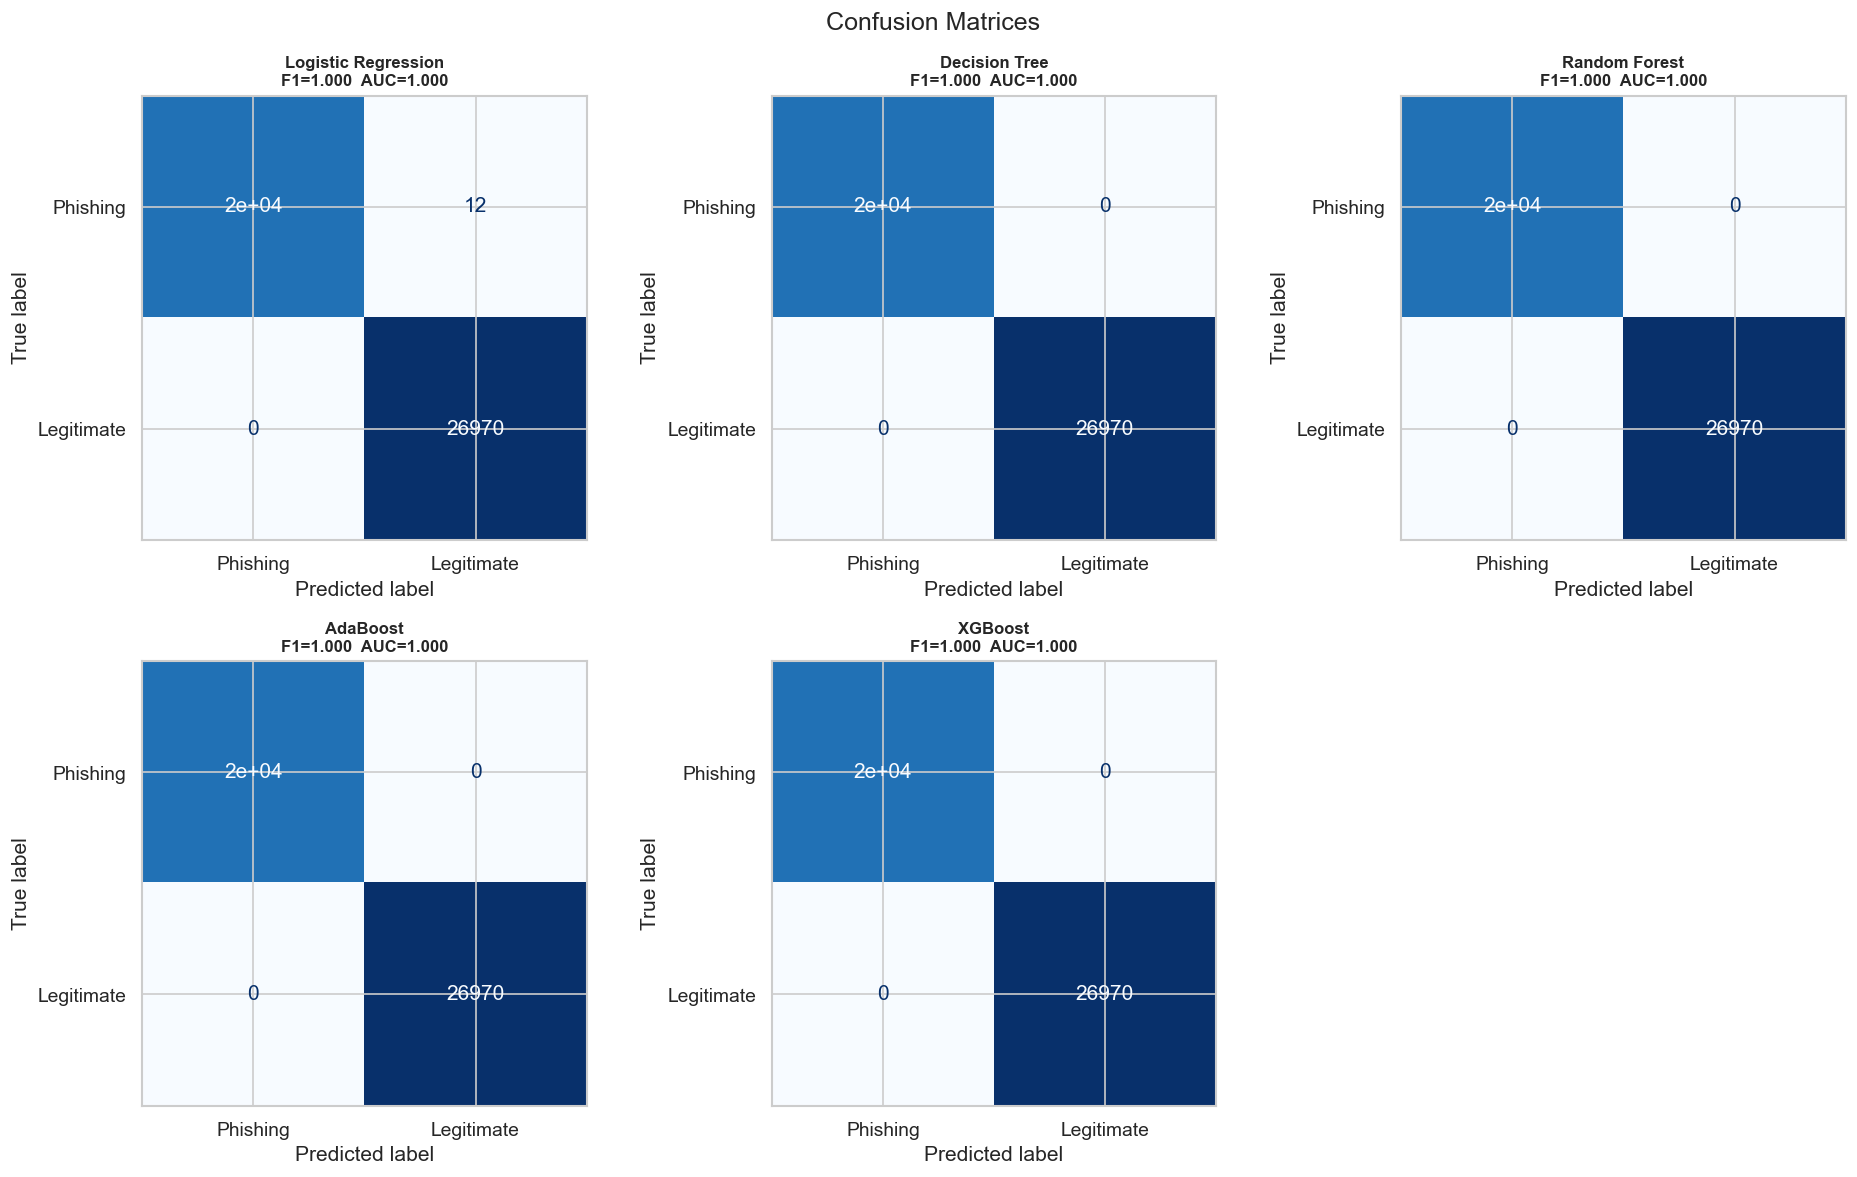

In [32]:
# ─── 9.3  Confusion Matrices ──────────────────────────────────────────────────
n_m   = len(models)
n_col = 3
n_row = (n_m + n_col - 1) // n_col

fig, axes = plt.subplots(n_row, n_col, figsize=(16, n_row*5))
fig.suptitle('Confusion Matrices', fontsize=15)
axes = axes.flatten()

for i, name in enumerate(models):
    cm = confusion_matrix(y_test_arr, preds[name]['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Phishing','Legitimate']).plot(
        ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(
        f'{name}\nF1={results_df.loc[name,"F1-Score"]:.3f}  AUC={results_df.loc[name,"AUC-ROC"]:.3f}',
        fontsize=10)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.tight_layout(); plt.show()

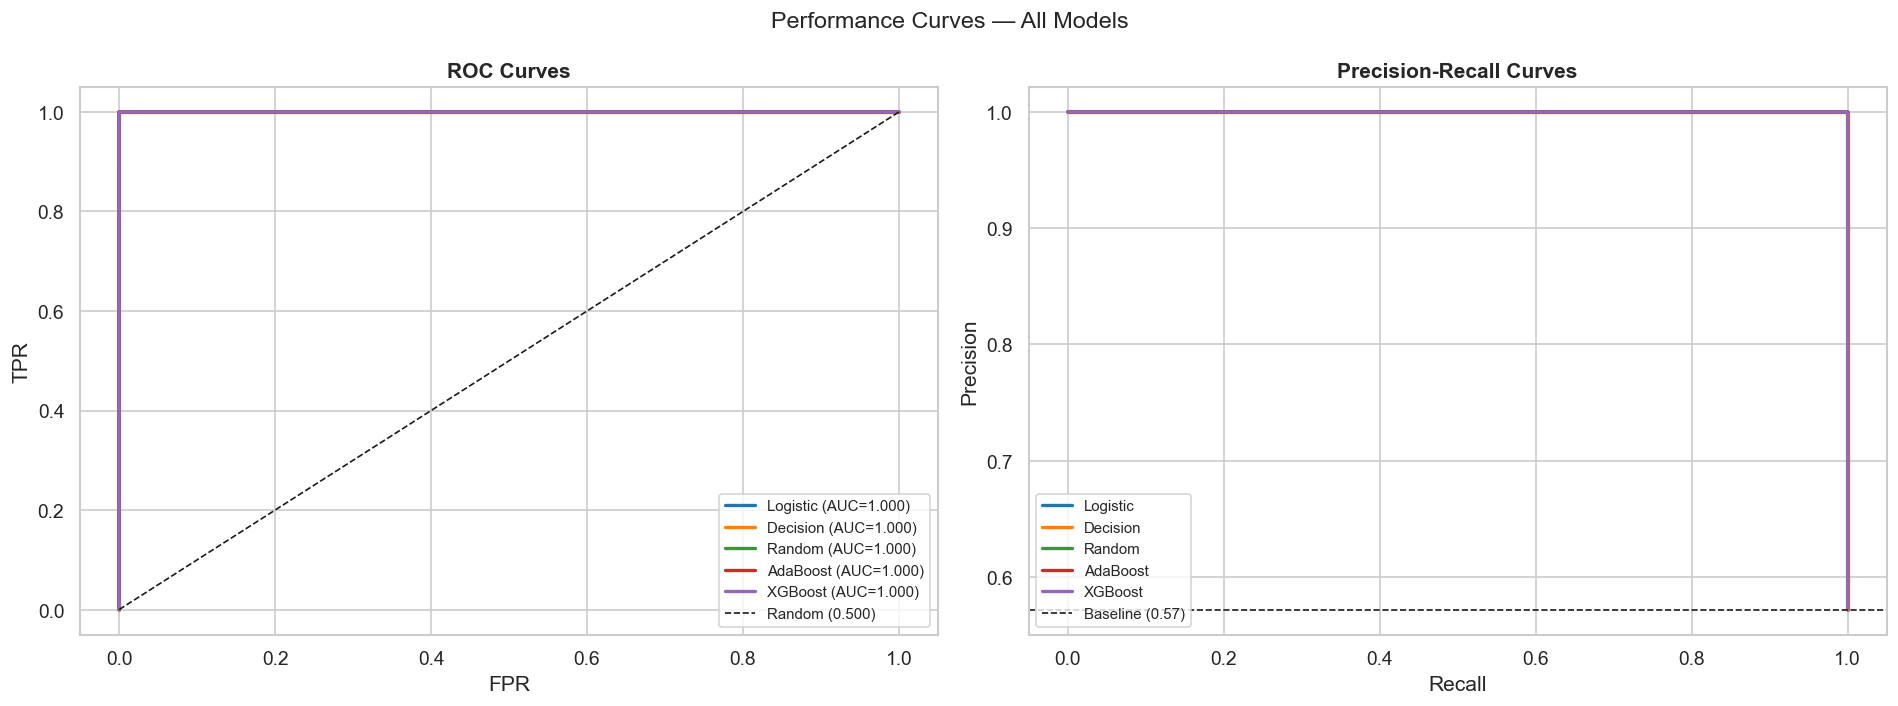

In [33]:
# ─── 9.4  ROC & Precision-Recall Curves ──────────────────────────────────────
palette = sns.color_palette('tab10', n_m)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Performance Curves — All Models', fontsize=14)

for i, name in enumerate(models):
    fpr, tpr, _ = roc_curve(y_test_arr, preds[name]['y_prob'])
    auc = test_results[name]['AUC-ROC']
    axes[0].plot(fpr, tpr, lw=2, color=palette[i],
                  label=f'{name.split()[0]} (AUC={auc:.3f})')

    prec, rec, _ = precision_recall_curve(y_test_arr, preds[name]['y_prob'])
    axes[1].plot(rec, prec, lw=2, color=palette[i], label=name.split()[0])

axes[0].plot([0,1],[0,1],'k--',lw=1, label='Random (0.500)')
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curves')
axes[0].legend(loc='lower right', fontsize=9)

axes[1].axhline(y_test_arr.mean(), color='k', ls='--', lw=1,
                 label=f'Baseline ({y_test_arr.mean():.2f})')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curves')
axes[1].legend(loc='lower left', fontsize=9)

plt.tight_layout(); plt.show()

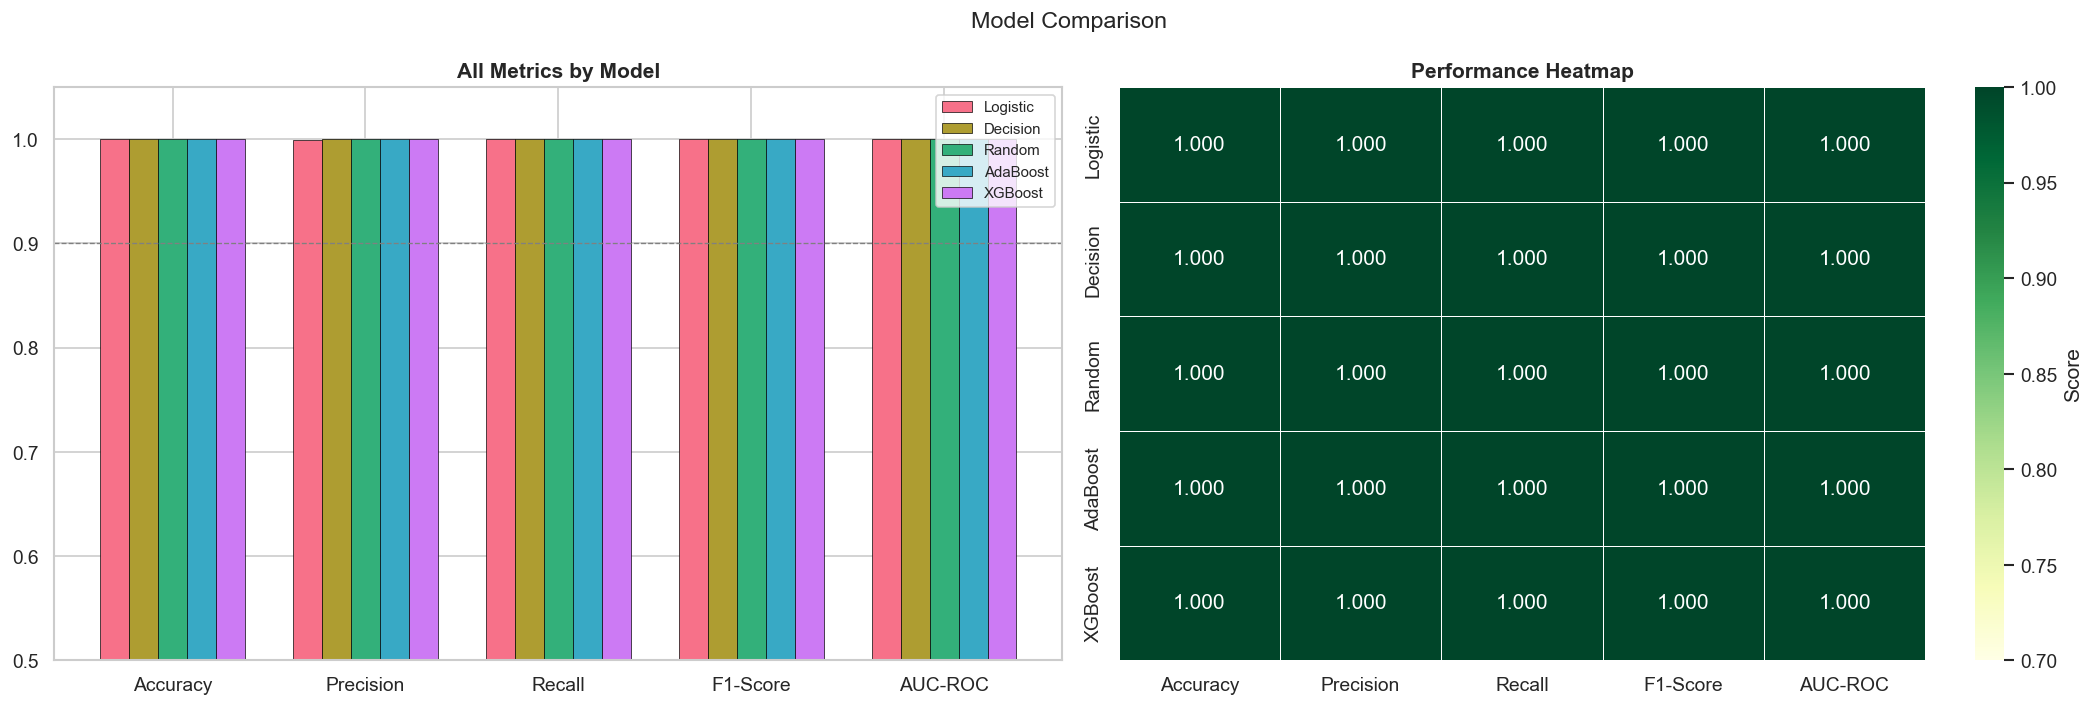

In [34]:
# ─── 9.5  Model Comparison Dashboard ─────────────────────────────────────────
metrics  = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']
s_names  = [n.split()[0] for n in results_df.index]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Model Comparison', fontsize=14)

# Grouped bar
x   = np.arange(len(metrics))
w   = 0.15
pal = sns.color_palette('husl', n_m)
for i, (name, row) in enumerate(results_df.iterrows()):
    axes[0].bar(x + i*w, row[metrics].values, w,
                 label=name.split()[0], color=pal[i], edgecolor='black', lw=0.4)
axes[0].set_xticks(x + w*(n_m-1)/2)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0.5, 1.05)
axes[0].axhline(0.9, color='gray', ls='--', lw=0.8)
axes[0].set_title('All Metrics by Model')
axes[0].legend(fontsize=9)

# Heatmap
hm = results_df[metrics].copy()
hm.index = s_names
sns.heatmap(hm.astype(float), annot=True, fmt='.3f', cmap='YlGn',
             ax=axes[1], linewidths=0.5, vmin=0.7, vmax=1.0,
             cbar_kws={'label':'Score'})
axes[1].set_title('Performance Heatmap')

plt.tight_layout(); plt.show()

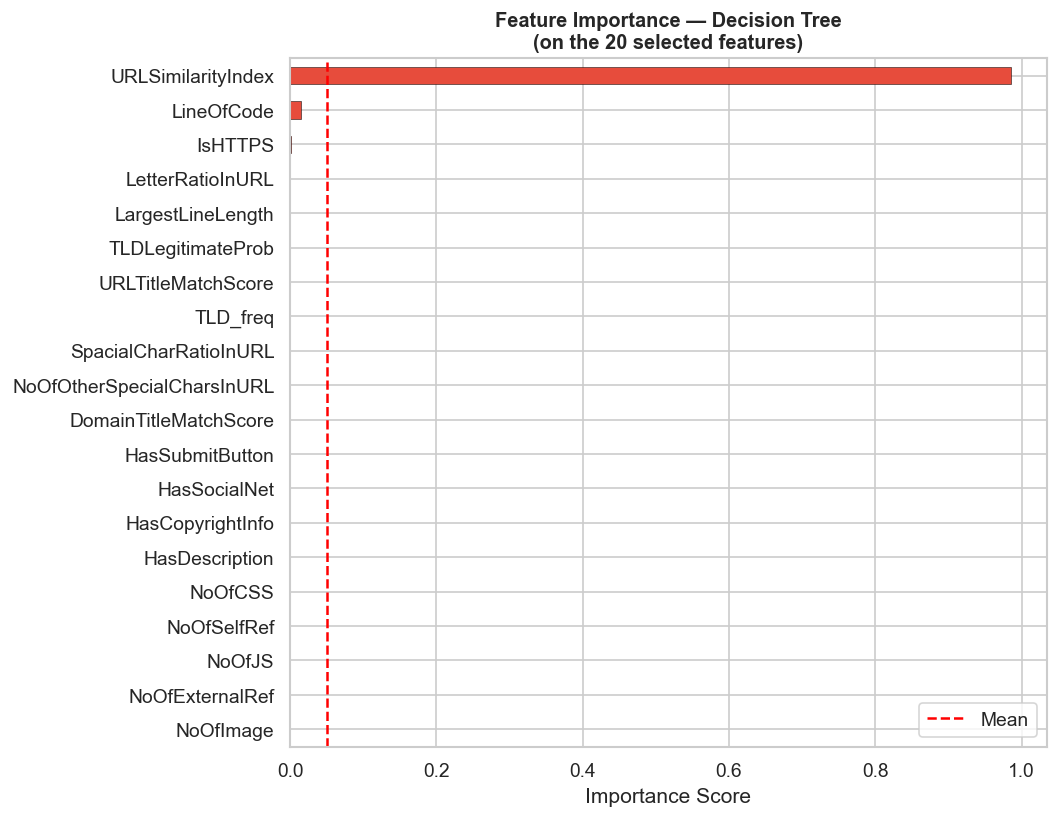

In [35]:
# ─── 9.6  Feature Importance of Best Model ────────────────────────────────────
best_model = trained[best_name]

if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=selected_features).sort_values()
    fig, ax = plt.subplots(figsize=(9, max(5, len(imp)*0.35)))
    clrs = [C['phish'] if i >= len(imp)-5 else C['blue'] for i in range(len(imp))]
    imp.plot(kind='barh', ax=ax, color=clrs, edgecolor='black', lw=0.3)
    ax.axvline(imp.mean(), color='red', ls='--', lw=1.5, label='Mean')
    ax.set_title(f'Feature Importance — {best_name}\n(on the {len(selected_features)} selected features)',
                  fontsize=12)
    ax.set_xlabel('Importance Score')
    ax.legend()
    plt.tight_layout(); plt.show()
elif hasattr(best_model, 'coef_'):
    coef = pd.Series(np.abs(best_model.coef_[0]), index=selected_features).sort_values()
    fig, ax = plt.subplots(figsize=(9, max(5, len(coef)*0.35)))
    coef.plot(kind='barh', ax=ax, color=C['blue'], edgecolor='black', lw=0.3)
    ax.set_title(f'|Coefficients| — {best_name}', fontsize=12)
    ax.set_xlabel('|Coefficient|')
    plt.tight_layout(); plt.show()

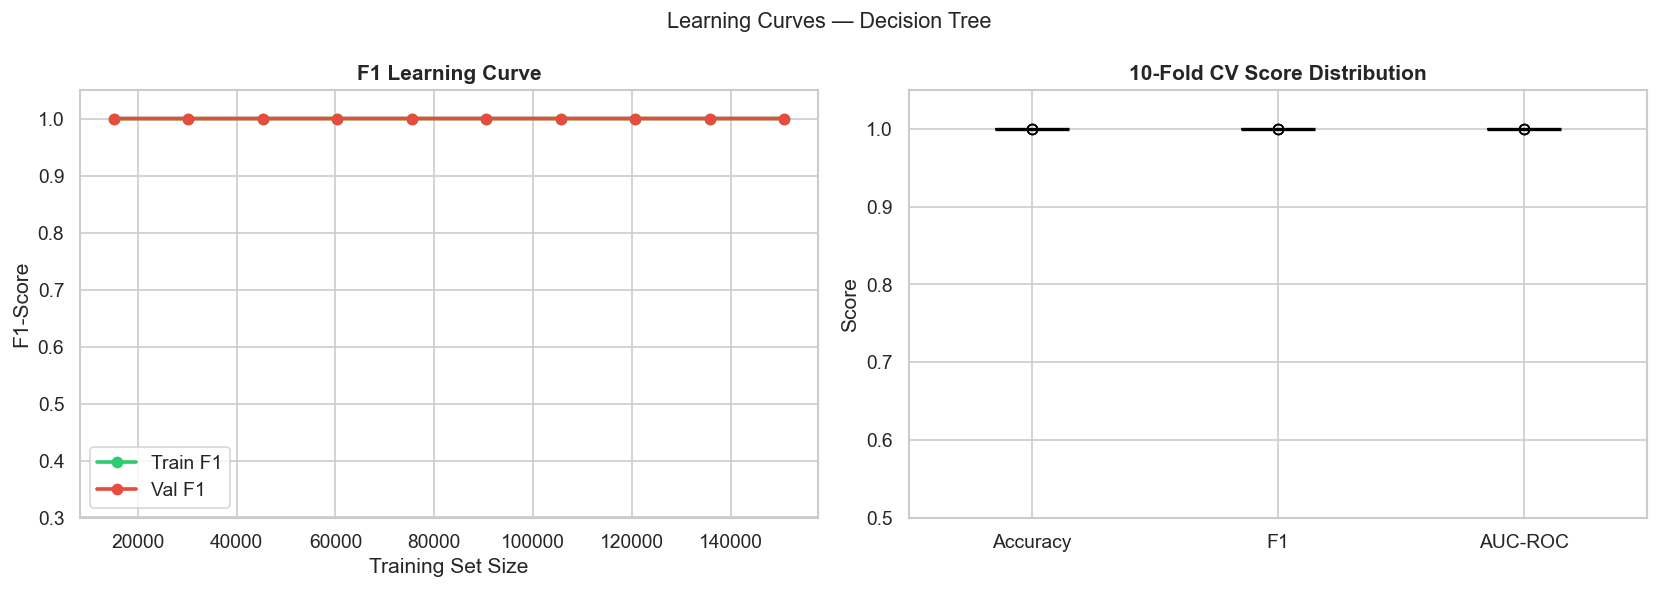

In [36]:
# ─── 9.7  Learning Curves ─────────────────────────────────────────────────────
best_info = models[best_name]

train_sizes, tr_scores, val_scores = learning_curve(
    trained[best_name], best_info['Xtr'], y_train_sel,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1', n_jobs=-1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Learning Curves — {best_name}', fontsize=13)

for ax, (tr, va, title) in zip(axes, [
    (tr_scores, val_scores, 'F1 Learning Curve'),
]):
    ax.plot(train_sizes, tr.mean(1), 'o-', color=C['legit'], lw=2.2, label='Train F1')
    ax.fill_between(train_sizes, tr.mean(1)-tr.std(1), tr.mean(1)+tr.std(1),
                     alpha=0.12, color=C['legit'])
    ax.plot(train_sizes, va.mean(1), 'o-', color=C['phish'], lw=2.2, label='Val F1')
    ax.fill_between(train_sizes, va.mean(1)-va.std(1), va.mean(1)+va.std(1),
                     alpha=0.12, color=C['phish'])
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('F1-Score')
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0.3, 1.05)

# CV fold distribution (10-fold boxplot)
detail = cross_validate(
    trained[best_name], best_info['Xtr'], y_train_sel,
    cv=StratifiedKFold(10, shuffle=True, random_state=RANDOM_STATE),
    scoring=['accuracy','f1','roc_auc']
)
bp = axes[1].boxplot(
    [detail['test_accuracy'], detail['test_f1'], detail['test_roc_auc']],
    patch_artist=True, labels=['Accuracy','F1','AUC-ROC'],
    medianprops=dict(color='black', lw=2)
)
for patch, col in zip(bp['boxes'], [C['blue'],C['phish'],C['legit']]):
    patch.set_facecolor(col+'80')
axes[1].set_title('10-Fold CV Score Distribution')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0.5, 1.05)

plt.tight_layout(); plt.show()

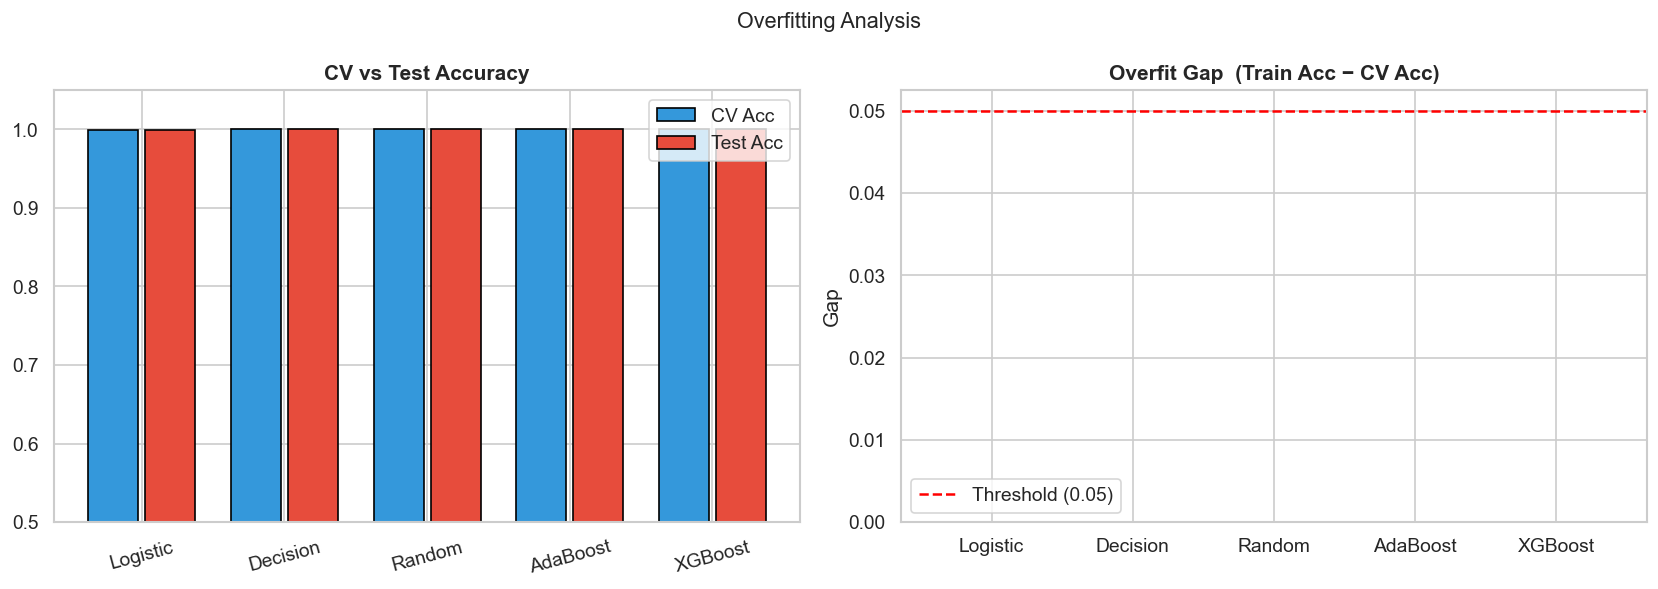

Logistic Regression                  Gap=0.0000  ✅ OK
Decision Tree                        Gap=-0.0000  ✅ OK
Random Forest                        Gap=0.0000  ✅ OK
AdaBoost                             Gap=0.0000  ✅ OK
XGBoost                              Gap=0.0000  ✅ OK


In [37]:
# ─── 9.8  Overfitting Analysis ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Overfitting Analysis', fontsize=13)

short = [n.split()[0] for n in cv_df.index]
x_pos = np.arange(len(cv_df))

axes[0].bar(x_pos-0.2, cv_df['CV Accuracy'], 0.35, label='CV Acc', color=C['blue'], edgecolor='black')
axes[0].bar(x_pos+0.2, results_df['Accuracy'].values, 0.35, label='Test Acc', color=C['phish'], edgecolor='black')
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(short, rotation=15)
axes[0].set_ylim(0.5, 1.05); axes[0].legend(); axes[0].set_title('CV vs Test Accuracy')

gaps   = cv_df['Overfit Gap'].values
clrs_g = [C['phish'] if g > 0.05 else C['legit'] for g in gaps]
axes[1].bar(short, gaps, color=clrs_g, edgecolor='black')
axes[1].axhline(0.05, color='red', ls='--', lw=1.5, label='Threshold (0.05)')
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Overfit Gap  (Train Acc − CV Acc)')
axes[1].set_ylabel('Gap'); axes[1].legend()

plt.tight_layout(); plt.show()

for name, g in zip(cv_df.index, gaps):
    status = '⚠️ OVERFIT' if g > 0.05 else '✅ OK'
    print(f'{name:<35}  Gap={g:.4f}  {status}')

---
## 10. 🏆 Final Summary

In [38]:
# ─── 10.1  Print Summary ──────────────────────────────────────────────────────
best = results_df.loc[best_name]

print('╔══════════════════════════════════════════════════════╗')
print('║          FINAL PIPELINE SUMMARY                     ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Dataset rows         : {len(df_raw):,}                        ║'[:56]+'║')
print(f'║  Original features    : {n_features}                         ║'[:56]+'║')
print(f'║  Selected features    : {len(selected_features)}  (CoD-safe ratio: {len(X_train_sel)/len(selected_features):.0f}:1)  ║'[:56]+'║')
print(f'║  Train / Test split   : 80% / 20%                   ║')
print(f'║  Imbalance handling   : {"SMOTE" if USE_SMOTE else "class_weight=balanced"}                 ║'[:56]+'║')
print('╠══════════════════════════════════════════════════════╣')
print('║  MODEL RESULTS (Test Set)                           ║')
print('╠══════════════════════════════════════════════════════╣')
for name, row in results_df.iterrows():
    mark = '🏆' if name == best_name else '  '
    print(f'║ {mark} {name[:18]:<18} F1={row["F1-Score"]:.3f}  AUC={row["AUC-ROC"]:.3f} ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  🥇 Best : {best_name[:20]:<20}                 ║'[:56]+'║')
print(f'║  Accuracy  : {best["Accuracy"]:.4f}                               ║'[:56]+'║')
print(f'║  Precision : {best["Precision"]:.4f}                               ║'[:56]+'║')
print(f'║  Recall    : {best["Recall"]:.4f}                               ║'[:56]+'║')
print(f'║  F1-Score  : {best["F1-Score"]:.4f}                               ║'[:56]+'║')
print(f'║  AUC-ROC   : {best["AUC-ROC"]:.4f}                               ║'[:56]+'║')
print('╚══════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════╗
║          FINAL PIPELINE SUMMARY                     ║
╠══════════════════════════════════════════════════════╣
║  Dataset rows         : 235,795                       ║
║  Original features    : 62                         ║║
║  Selected features    : 20  (CoD-safe ratio: 9432:1)  ║
║  Train / Test split   : 80% / 20%                   ║
║  Imbalance handling   : class_weight=balanced         ║
╠══════════════════════════════════════════════════════╣
║  MODEL RESULTS (Test Set)                           ║
╠══════════════════════════════════════════════════════╣
║    Logistic Regressio F1=1.000  AUC=1.000 ║
║ 🏆 Decision Tree      F1=1.000  AUC=1.000 ║
║    Random Forest      F1=1.000  AUC=1.000 ║
║    AdaBoost           F1=1.000  AUC=1.000 ║
║    XGBoost            F1=1.000  AUC=1.000 ║
╠══════════════════════════════════════════════════════╣
║  🥇 Best : Decision Tree                        ║║
║  Accuracy  : 1.0000               

In [ ]:
# ─── 10.2  Save Results ───────────────────────────────────────────────────────
results_df.to_csv('test_results.csv')
cv_df.to_csv('cv_results.csv')
pd.DataFrame({'selected_features': selected_features}).to_csv('selected_features.csv', index=False)

print('✅ test_results.csv')
print('✅ cv_results.csv')
print('✅ selected_features.csv')
print('\n🎉 Pipeline complete!')